In [1]:
import jax.numpy as jnp
import jax
import flax.nnx as nnx
import matplotlib.pyplot as plt
from typing import NamedTuple, Callable

In [117]:
def f(u: Callable, x_u: jax.Array):
    """ u is a NN """
    # this could just take u as a jax array, but this allows for derivatives
    return 0.5 * u(x_u)**2

def u0(x: jax.Array, uL: jax.Array, uR: jax.Array):
    return jnp.where(x >= 0, uR, uL)

def utrue(x: jax.Array, t: jax.Array, uL: jax.Array, uR: jax.Array):
    s = jnp.where(t > 0, x / t, jnp.nan)
    rarefaction = jnp.where(s > uR, uR, jnp.where(s < uL, uL, s))
    shock_speed = 0.5 * (uL + uR)
    shock = jnp.where(s < shock_speed, uL, uR)
    ans = jnp.where(jnp.isnan(s), u0(x, uL, uR), jnp.where(uL < uR, rarefaction, shock))
    return ans

def omega(x: jax.Array, t: jax.Array, x0: float, x1: float, T: float):
    norm = 4.0 / (T * (x1 - x0)**2)
    ans = norm * (x - x0) * (x1 - x) * (T - t)
    in_bounds = jnp.logical_and(x >= x0, x<= x1)
    in_time = jnp.logical_and(t >= 0, t <= T)
    return ans * in_bounds * in_time


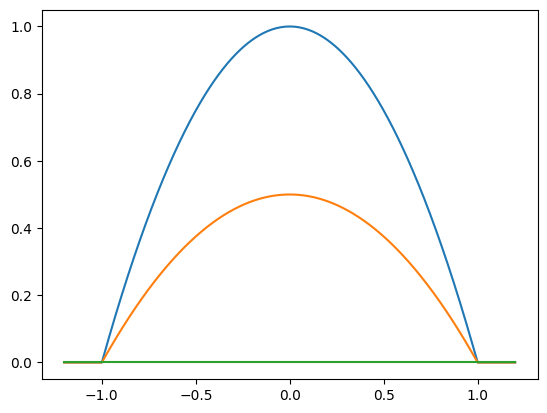

In [118]:
x0 = -1; x1 = 1; T = 1

xlist = jnp.linspace(-1.2, 1.2, 1000)

plt.plot(xlist, omega(xlist, jnp.full_like(xlist, 0),   x0, x1, T))
plt.plot(xlist, omega(xlist, jnp.full_like(xlist, 0.5), x0, x1, T))
plt.plot(xlist, omega(xlist, jnp.full_like(xlist, 1),   x0, x1, T))

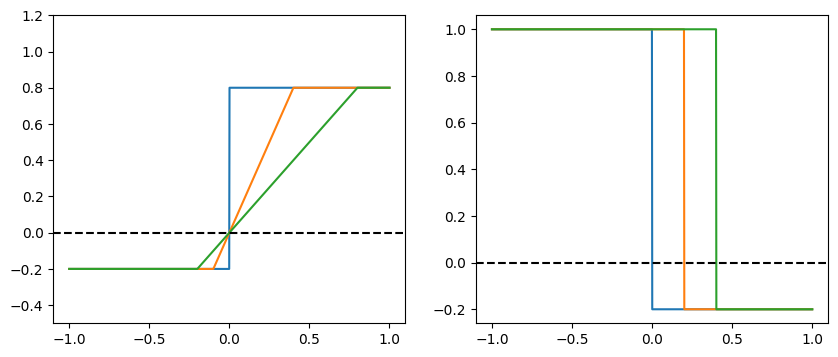

In [119]:
xlist = jnp.linspace(-1, 1, 1000)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for T in [0, 0.5, 1]:
    axs[0].plot(xlist, utrue(xlist, T, -0.2, 0.8))
    axs[1].plot(xlist, utrue(xlist, T, 1, -0.2))

axs[0].set_ylim(-0.5, 1.2)
axs[0].axhline(0, c='k', ls = 'dashed')
# axs[1].set_ylim(-0.5, 1.2)
axs[1].axhline(0, c='k', ls = 'dashed')
plt.show()

In [167]:
class MLP(nnx.Module):
    def __init__(self, dims, *, rngs: nnx.Rngs):
        self.layers = nnx.List([nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(len(dims) - 1)])

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = nnx.tanh(layer(x))
        return self.layers[-1](x).squeeze(-1)


def init_nn(in_dim=4, width=32, depth=3, out_dim=1, *, seed=0):
    dims = [in_dim] + [width] * depth + [out_dim]
    return MLP(dims, rngs=nnx.Rngs(seed))

x0 = -1; x1 = 1; T = 1

u = init_nn()
phi_net = init_nn(in_dim=2, seed=1)
# phi = lambda x: omega(x[...,0], x[...,1], x0, x1, T) * phi_net(x)
# phi = lambda x: omega(x[...,0], x[...,1], x0, x1, T)

a = jnp.array([0.1])
x_u = jnp.stack([a, a, a, a], axis=-1)
x_phi = jnp.stack([a, a], axis=-1)
print(u(x_u))
print(phi_net(x_phi))
print(phi(x_phi))

[-0.14531763]
[0.04404223]
[0.03924163]


In [194]:
def loss(u, phi, x, t, uL, uR, u0, lam_ics=2.0):
    # partial_t u + partial_x f = 0
    def _loss_single(u, phi, x, t, uL, uR, u0):
        uL_b = jnp.broadcast_to(uL, x.shape)
        uR_b = jnp.broadcast_to(uR, x.shape)
        x_u = jnp.stack([x, t, uL_b, uR_b], axis=-1)
        x_phi = jnp.stack([x, t], axis=-1)
        u_eval = u(x_u)
        f_eval = f(u, x_u)

        grad_phi = jax.vmap(jax.grad(phi))(x_phi)
        phi_x, phi_t = grad_phi[...,0], grad_phi[...,1]

        # now add the weak form
        integral_term = jnp.mean(u_eval * phi_t + f_eval * phi_x)

        # add BC term
        x_phi_t0 = jnp.stack([x, jnp.full_like(x, 0)], axis=-1)
        bc_term = jnp.mean(u0(x, uL, uR) * phi(x_phi_t0))

        total_integral = (integral_term + bc_term)**2

        # now normalize by phi, so that the network doesnt do phi -> inf
        norm = jnp.mean(phi(x_phi)**2)

        return total_integral / norm
    
    # vmap over uL and uR (assumed matching-shape arrays of scalars) while broadcasting others
    # Use in_axes to map the 5th and 6th arguments (uL, uR)
    all_losses = jax.vmap(
        _loss_single,
        in_axes=(None, None, None, None, 0, 0, None)
    )(u, phi, x, t, uL, uR, u0)

    pde_loss = jnp.mean(all_losses)

    # now add ics loss
    x_phi_t0 = jnp.stack([x, jnp.full_like(x, 0), jnp.full_like(x, uL), jnp.full_like(x, uR)], axis=-1)
    ics_loss = jnp.mean((u(x_phi_t0) - u0(x, uL, uR))**2)

    return pde_loss + lam_ics * ics_loss

In [195]:
a = jnp.array([0.1])

loss(u, phi_net, a, a, a, a, u0)

Array(38.10157, dtype=float32)

In [196]:
from jax import random as jr

class R2QuasirandomSampler:
    """R2 quasirandom samples in (drho, dp, du)."""

    # R2 quasirandom additive recurrence. Golden ratios for d=1..12.
    _R2_GOLDEN = jnp.array([
        1.6180339887498949, 1.3247179572447463, 1.2207440846057596,
        1.1673039782614185, 1.1347241384015194, 1.1127756842787053,
        1.0969815577985598, 1.0850702454914507, 1.0757660660868371,
        1.0682971889208415, 1.0621691678642553, 1.0570505752212287,
    ])

    NDIM = 3

    def draw_batch(self, rng, batch_size: int, dim: int, bounds: jax.Array) -> jnp.ndarray:
        g = self._R2_GOLDEN[dim - 1]
        powers = jnp.arange(1, dim + 1, dtype=jnp.float32)
        a = g ** (-powers)
        x0 = jr.uniform(rng, (dim,), minval=0.0, maxval=1.0)
        n = jnp.arange(batch_size, dtype=jnp.float32)[:, None]
        out_unit = jnp.mod(x0[None, :] + n * a[None, :], 1.0)
        lo = bounds[:, 0]
        hi = bounds[:, 1]
        # Broadcast lo/hi so shapes work out
        return lo + (hi - lo) * out_unit
 

In [218]:
import optax
from tqdm import tqdm

x0 = -1; x1 = 1; T = 1

u = init_nn()
phi_net = init_nn(in_dim=2, seed=1)

lr = 1e-3
n_steps_u = 2
n_steps_phi = 5
batch_size = 1000
nprob = 1
opt_u =   nnx.Optimizer(u,       optax.adamw(lr),                                wrt=nnx.Param)
opt_phi = nnx.Optimizer(phi_net, optax.chain(optax.scale(-1.0), optax.adam(lr)), wrt=nnx.Param)

@nnx.jit
def train_step_u(u, optimizer, key):
    # Sample nprob (uL, uR) pairs and batch_size (x, t) points, then take their cross product.
    sampler = R2QuasirandomSampler()
    key_ur, key_xt = jr.split(key)
    # ur_bounds = jnp.array([[-1.0, 1.0], [-1.0, 1.0]])
    ur_bounds = jnp.array([[-0.2, -0.2], [0.8, 0.8]])
    xt_bounds = jnp.array([[x0, x1], [0.0, T]])
    ur = sampler.draw_batch(key_ur, nprob, dim=2, bounds=ur_bounds)       # (nprob, 2)
    xt = sampler.draw_batch(key_xt, batch_size, dim=2, bounds=xt_bounds)  # (batch_size, 2)

    uL, uR = ur[:, 0], ur[:, 1]
    x, t = xt[:, 0], xt[:, 1]

    phi = lambda x: omega(x[...,0], x[...,1], x0, x1, T) * phi_net(x)
    loss_val, grads = nnx.value_and_grad(lambda u: loss(u, phi, x, t, uL, uR, u0))(u)
    optimizer.update(u, grads)

    return loss_val

@nnx.jit
def train_step_phi(phi_net, optimizer, key):
    # Sample nprob (uL, uR) pairs and batch_size (x, t) points, then take their cross product.
    sampler = R2QuasirandomSampler()
    key_ur, key_xt = jr.split(key)
    # ur_bounds = jnp.array([[-1.0, 1.0], [-1.0, 1.0]])
    ur_bounds = jnp.array([[-0.2, -0.2], [0.8, 0.8]])
    xt_bounds = jnp.array([[x0, x1], [0.0, T]])
    ur = sampler.draw_batch(key_ur, nprob, dim=2, bounds=ur_bounds)       # (nprob, 2)
    xt = sampler.draw_batch(key_xt, batch_size, dim=2, bounds=xt_bounds)  # (batch_size, 2)

    uL, uR = ur[:, 0], ur[:, 1]
    x, t = xt[:, 0], xt[:, 1]

    loss_val, grads = nnx.value_and_grad(
            lambda pn: loss(u, lambda x: omega(x[...,0], x[...,1], x0, x1, T) * pn(x), 
                            x, t, uL, uR, u0)
        )(phi_net)
    optimizer.update(phi_net, grads)

    return loss_val

def train_u(u, optimizer, n_steps, key, losses=[], use_tqdm=False):
    if use_tqdm:
        pbar = tqdm(range(n_steps), desc="Minimizing u")
    else:
        pbar = range(n_steps)

    for step in pbar:
        key, sub = jax.random.split(key)
        losses.append(float(train_step_u(u, optimizer, sub)))
        if step % 10 == 0 and use_tqdm:
            pbar.set_postfix(loss=losses[-1])
    
    return losses, u

def train_phi(phi_net, optimizer, n_steps, key, losses=[], use_tqdm=False):
    if use_tqdm:
        pbar = tqdm(range(n_steps), desc="Minimizing u")
    else:
        pbar = range(n_steps)

    for step in pbar:
        key, sub = jax.random.split(key)
        losses.append(float(train_step_phi(phi_net, optimizer, sub)))
        if step % 10 == 0 and use_tqdm:
            pbar.set_postfix(loss=losses[-1])
    
    return losses, phi_net

key = jax.random.PRNGKey(0)
losses, u = train_u(u, opt_u, 10*n_steps_u, key)
for i in tqdm(range(5000)):
    losses, phi_net = train_phi(phi_net, opt_phi, n_steps_phi, key, losses=losses)
    losses, u = train_u(u, opt_u, n_steps_u, key, losses=losses)

    if i % 500 == 0:
        phi_net = init_nn(in_dim=2, seed=i)
        opt_phi = nnx.Optimizer(phi_net, optax.adam(lr), wrt=nnx.Param)
        opt_u = nnx.Optimizer(u, optax.adamw(lr), wrt=nnx.Param)


100%|██████████| 5000/5000 [01:31<00:00, 54.78it/s]


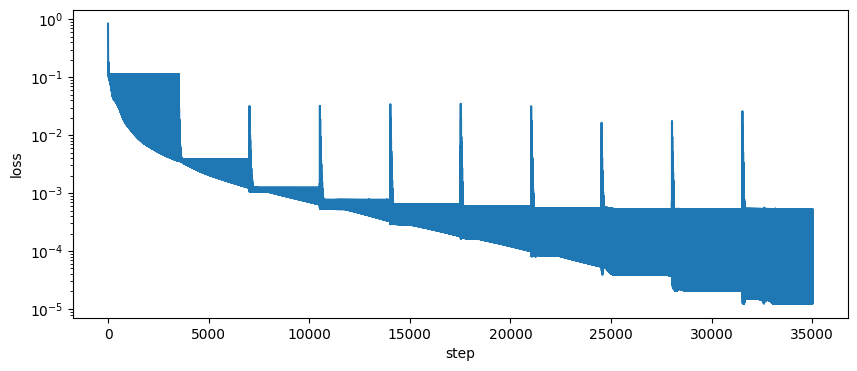

In [222]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(losses)
ax.set(yscale='log', xlabel='step', ylabel='loss')
plt.show()

In [212]:
lr = 1e-3
# print(lr)
for _ in range(40):
    lr *= 0.98
    # print(lr)

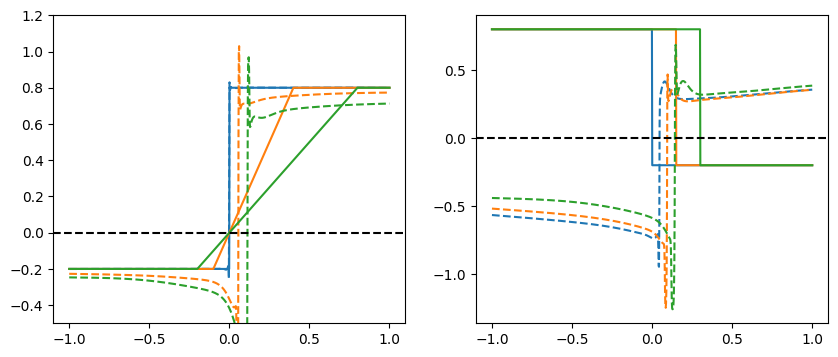

In [223]:
xlist = jnp.linspace(-1, 1, 1000)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for T in [0, 0.5, 1]:
    uL = -0.2 ; uR = 0.8
    l = axs[0].plot(xlist, utrue(xlist, T, uL, uR))
    uhat = u(jnp.stack([xlist, jnp.full_like(xlist, T), jnp.full_like(xlist, uL), jnp.full_like(xlist, uR)], axis=-1))
    axs[0].plot(xlist, uhat, '--', c=l[0].get_color())

    uL = 0.8 ; uR = -0.2
    l = axs[1].plot(xlist, utrue(xlist, T, uL, uR))
    uhat = u(jnp.stack([xlist, jnp.full_like(xlist, T), jnp.full_like(xlist, uL), jnp.full_like(xlist, uR)], axis=-1))
    axs[1].plot(xlist, uhat, '--', c=l[0].get_color())

axs[0].set_ylim(-0.5, 1.2)
axs[0].axhline(0, c='k', ls = 'dashed')
# axs[1].set_ylim(-0.5, 1.2)
axs[1].axhline(0, c='k', ls = 'dashed')
plt.show()

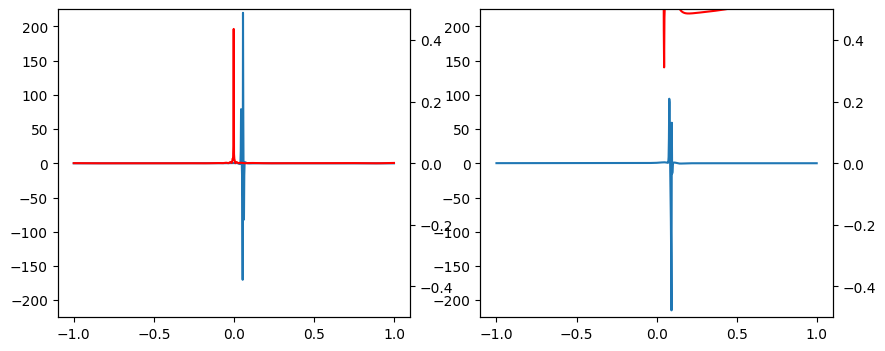

In [230]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

for uL, uR, ax in zip([-0.2, 0.8], [0.8, -0.2], axs):

    xlist = jnp.linspace(-1, 1, 1000)
    x_u = jnp.stack([xlist, jnp.full_like(xlist, 0.5), jnp.full_like(xlist, uL), jnp.full_like(xlist, uR)], axis=-1)
    x_u_t0 = jnp.stack([xlist, jnp.full_like(xlist, 0.), jnp.full_like(xlist, uL), jnp.full_like(xlist, uR)], axis=-1)

    grad_u = jax.vmap(jax.grad(u))(x_u)
    u_t = grad_u[...,1]

    fu = lambda x_u: f(u, x_u)
    grad_f = jax.vmap(jax.grad(fu))(x_u)
    f_x = grad_f[...,0]

    u_eval = u(x_u_t0)
    u0_eval = u0(xlist, uL, uR)

    ax.plot(xlist, u_t + f_x)
    ax2 = ax.twinx()
    ax2.plot(xlist, jnp.sqrt((u_eval - u0_eval)**2), c='r')

    ax.set(ylim=(-225, 225))
    ax2.set(ylim=(-0.5, 0.5))

    # print(jnp.sqrt((u_eval - u0_eval)**2))